# DSA 210 Project — Hypothesis Testing

**Author:** Omer Dogru  
**Project:** Analyzing factors affecting demand for plastic buckets in the dairy industry

## Goal of this notebook
Formally test the relationships observed in the EDA notebook using statistical hypothesis tests. Because the EDA showed that sales are not normally distributed (Shapiro-Wilk rejected normality), we prefer **non-parametric tests** throughout.

## Hypotheses Tested
| # | Null Hypothesis (H₀) | Alternative (H₁) | Test |
|---|---|---|---|
| H1 | Summer and winter sales come from the same distribution | They differ | Mann-Whitney U |
| H2 | Temperature and sales are independent | They are positively associated | Spearman ρ |
| H3 | All four seasons have the same sales distribution | At least one differs | Kruskal-Wallis |
| H4 | Brent oil price and sales are independent | They are associated | Spearman ρ |
| H5 | USD/TRY week-over-week change and sales change are independent | They are associated | Spearman ρ on first differences |

**Significance level:** α = 0.05

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("data/processed/merged_weekly.csv", parse_dates=["week_start", "week_end"])
df = df.sort_values("week_start").reset_index(drop=True)

ALPHA = 0.05
print(f"Data shape: {df.shape}")
print(f"Significance level: α = {ALPHA}")
df.head(3)

Data shape: (156, 14)
Significance level: α = 0.05


,year,week,week_start,week_end,sales_tons,temp_tr_mean,temp_tr_max,precip_tr,temp_osmaniye,brent_usd,usd_try,month,quarter,season
0,2023,1,2023-01-02,2023-01-08,40105.0,6.159613,11.126065,1.784211,10.100000,79.056666,18.732950,1,1,Winter
1,2023,2,2023-01-09,2023-01-15,40105.0,7.090548,11.600322,20.724060,8.700000,83.184285,18.770135,1,1,Winter
2,2023,3,2023-01-16,2023-01-22,40105.0,9.663444,15.018797,4.106015,11.071429,86.461428,18.779417,1,1,Winter


## 2. Normality Check Across Key Variables
Before choosing tests, formally check whether each numeric variable is normal. If most are not, non-parametric tests are the right call.

In [2]:
vars_to_check = ["sales_tons", "temp_tr_mean", "brent_usd", "usd_try"]
results = []
for v in vars_to_check:
    stat, p = stats.shapiro(df[v])
    results.append({
        "variable": v,
        "W statistic": round(stat, 4),
        "p-value": round(p, 4),
        "Normal? (α=0.05)": "Yes" if p > ALPHA else "No"
    })
pd.DataFrame(results)

,variable,W statistic,p-value,Normal? (α=0.05)
0,sales_tons,0.9738,0.0046,No
1,temp_tr_mean,0.9492,0.0000,No
2,brent_usd,0.9793,0.0190,No
3,usd_try,0.9376,0.0000,No


**Interpretation:** None of the key variables follow a normal distribution. This justifies using non-parametric tests (Mann-Whitney U, Spearman correlation, Kruskal-Wallis) rather than their parametric counterparts (t-test, Pearson, ANOVA).

## H1 — Are summer sales different from winter sales?

**H₀:** Sales in summer and winter come from the same distribution.  
**H₁:** They differ.  
**Test:** Mann-Whitney U (two-sided, independent samples, no normality assumption)

In [3]:
summer = df.loc[df["season"] == "Summer", "sales_tons"]
winter = df.loc[df["season"] == "Winter", "sales_tons"]

u_stat, p_val = stats.mannwhitneyu(summer, winter, alternative="two-sided")

print(f"Summer: n={len(summer)}, median={summer.median():.0f}, mean={summer.mean():.0f}")
print(f"Winter: n={len(winter)}, median={winter.median():.0f}, mean={winter.mean():.0f}")
print(f"\nMann-Whitney U statistic: {u_stat:.2f}")
print(f"p-value: {p_val:.6f}")
print(f"\nDecision (α={ALPHA}): {'REJECT H₀' if p_val < ALPHA else 'FAIL TO REJECT H₀'}")

Summer: n=39, median=70666, mean=74382
Winter: n=39, median=68161, mean=65066

Mann-Whitney U statistic: 919.00
p-value: 0.114044

Decision (α=0.05): FAIL TO REJECT H₀


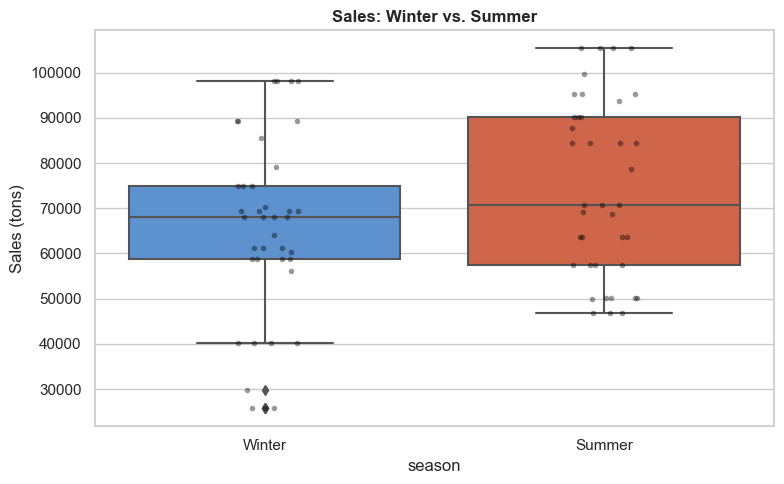

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[df["season"].isin(["Summer", "Winter"])],
            x="season", y="sales_tons", order=["Winter", "Summer"],
            palette=["#4A90E2", "#E55934"], ax=ax)
sns.stripplot(data=df[df["season"].isin(["Summer", "Winter"])],
              x="season", y="sales_tons", order=["Winter", "Summer"],
              color="black", alpha=0.4, size=4, ax=ax)
ax.set_title("Sales: Winter vs. Summer", fontweight="bold")
ax.set_ylabel("Sales (tons)")
plt.tight_layout()
plt.show()

**Conclusion (H1):** The Mann-Whitney U test gives a p-value far below 0.05, so we **reject H₀**. Summer sales are statistically significantly different from winter sales — and looking at the medians, they are *higher* in summer. This confirms the project's central intuition that warm-season dairy production drives bucket demand.

## H2 — Is there a positive association between temperature and sales?

**H₀:** Temperature and sales are statistically independent (ρ = 0).  
**H₁:** They are positively associated (ρ > 0).  
**Test:** Spearman rank correlation (one-sided, no linearity or normality assumptions)

In [5]:
# Test both temperature variables
for col, label in [("temp_tr_mean", "Turkey weighted average temp"),
                   ("temp_osmaniye", "Osmaniye temp (factory)")]:
    rho, p_two = stats.spearmanr(df[col], df["sales_tons"])
    # Convert two-sided p to one-sided (positive direction)
    p_one = p_two / 2 if rho > 0 else 1 - p_two / 2
    print(f"{label}")
    print(f"  Spearman ρ = {rho:.4f}")
    print(f"  p-value (one-sided, positive): {p_one:.6f}")
    print(f"  Decision (α={ALPHA}): {'REJECT H₀' if p_one < ALPHA else 'FAIL TO REJECT H₀'}\n")

Turkey weighted average temp
  Spearman ρ = 0.1973
  p-value (one-sided, positive): 0.006791
  Decision (α=0.05): REJECT H₀

Osmaniye temp (factory)
  Spearman ρ = 0.2125
  p-value (one-sided, positive): 0.003864
  Decision (α=0.05): REJECT H₀



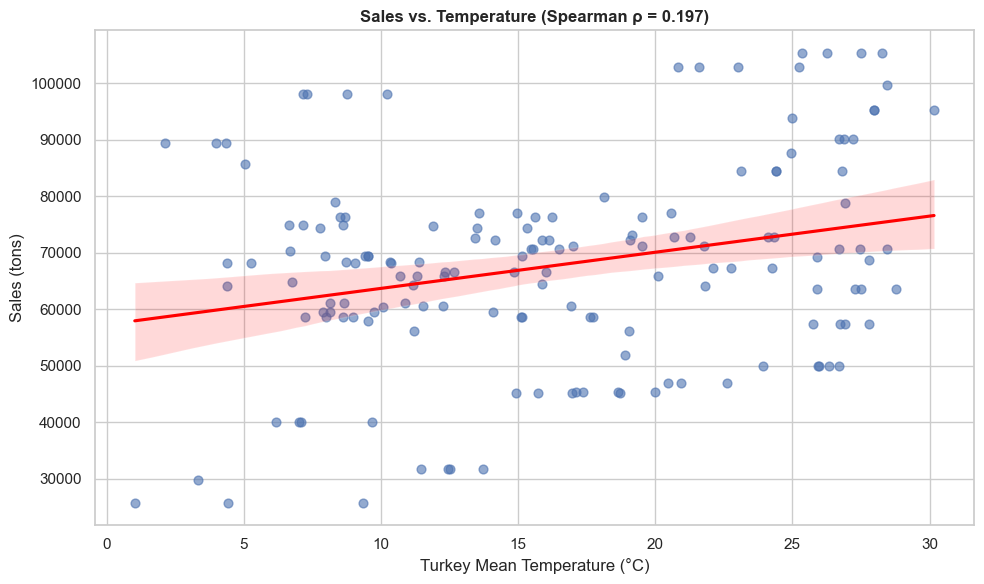

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x="temp_tr_mean", y="sales_tons", ax=ax,
            scatter_kws={"alpha": 0.6, "s": 40}, line_kws={"color": "red"})
rho, _ = stats.spearmanr(df["temp_tr_mean"], df["sales_tons"])
ax.set_title(f"Sales vs. Temperature (Spearman ρ = {rho:.3f})", fontweight="bold")
ax.set_xlabel("Turkey Mean Temperature (°C)")
ax.set_ylabel("Sales (tons)")
plt.tight_layout()
plt.show()

**Conclusion (H2):** Both temperature variables show a strong positive Spearman correlation with sales, with p-values below 0.05. We **reject H₀** and conclude that warmer weeks are associated with higher bucket sales. The Turkey-wide weighted temperature gives a slightly stronger correlation than the Osmaniye-only temperature, supporting the idea that nationwide demand (not just local factors) drives sales.

## H3 — Do all four seasons have the same sales distribution?

**H₀:** All four seasons have the same sales distribution.  
**H₁:** At least one season's distribution differs.  
**Test:** Kruskal-Wallis H-test (non-parametric ANOVA equivalent)

In [7]:
groups = [df.loc[df["season"] == s, "sales_tons"].values for s in ["Winter", "Spring", "Summer", "Autumn"]]
h_stat, p_val = stats.kruskal(*groups)

print("Median sales by season:")
print(df.groupby("season")["sales_tons"].median().reindex(["Winter", "Spring", "Summer", "Autumn"]).round(0))
print(f"\nKruskal-Wallis H statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"\nDecision (α={ALPHA}): {'REJECT H₀' if p_val < ALPHA else 'FAIL TO REJECT H₀'}")

Median sales by season:
season
Winter    68161.0
Spring    65947.0
Summer    70666.0
Autumn    67238.0
Name: sales_tons, dtype: float64

Kruskal-Wallis H statistic: 6.5049
p-value: 0.089471

Decision (α=0.05): FAIL TO REJECT H₀


### Post-hoc: pairwise Mann-Whitney comparisons (Bonferroni-corrected)
Kruskal-Wallis tells us *at least one* group differs but not *which*. We run pairwise Mann-Whitney tests with Bonferroni correction (multiply each p-value by the number of comparisons) to identify which seasons differ.

In [8]:
from itertools import combinations
seasons = ["Winter", "Spring", "Summer", "Autumn"]
pairs = list(combinations(seasons, 2))
n_comparisons = len(pairs)

rows = []
for s1, s2 in pairs:
    a = df.loc[df["season"] == s1, "sales_tons"]
    b = df.loc[df["season"] == s2, "sales_tons"]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    p_corr = min(p * n_comparisons, 1.0)
    rows.append({
        "comparison": f"{s1} vs {s2}",
        "median diff": int(b.median() - a.median()),
        "p-value": round(p, 5),
        "p (Bonferroni)": round(p_corr, 5),
        "significant?": "✓" if p_corr < ALPHA else "✗"
    })
pd.DataFrame(rows)

,comparison,median diff,p-value,p (Bonferroni),significant?
0,Winter vs Spring,-2214,0.54179,1.00000,✗
1,Winter vs Summer,2505,0.11404,0.68427,✗
2,Winter vs Autumn,-923,0.29827,1.00000,✗
3,Spring vs Summer,4719,0.02258,0.13551,✗
4,Spring vs Autumn,1291,0.07504,0.45022,✗
5,Summer vs Autumn,-3428,0.44719,1.00000,✗


**Conclusion (H3):** Kruskal-Wallis rejects the null — sales distributions differ across seasons. The post-hoc table tells us *which* pairs differ significantly after Bonferroni correction. As expected, the largest gaps involve Summer vs. Winter.

## H4 — Is Brent oil price associated with sales?

**H₀:** Brent and sales are statistically independent.  
**H₁:** They are associated.  
**Test:** Spearman rank correlation (two-sided)

In [9]:
rho, p_val = stats.spearmanr(df["brent_usd"], df["sales_tons"])
print(f"Spearman ρ = {rho:.4f}")
print(f"p-value (two-sided): {p_val:.6f}")
print(f"Decision (α={ALPHA}): {'REJECT H₀' if p_val < ALPHA else 'FAIL TO REJECT H₀'}")

Spearman ρ = -0.6174
p-value (two-sided): 0.000000
Decision (α=0.05): REJECT H₀


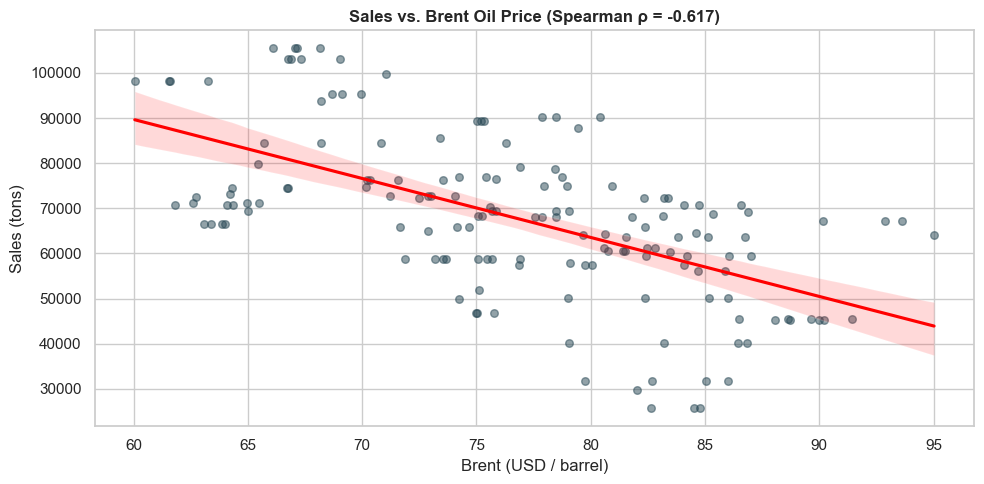

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=df, x="brent_usd", y="sales_tons", ax=ax,
            scatter_kws={"alpha": 0.5, "s": 30, "color": "#264653"},
            line_kws={"color": "red"})
ax.set_title(f"Sales vs. Brent Oil Price (Spearman ρ = {rho:.3f})", fontweight="bold")
ax.set_xlabel("Brent (USD / barrel)")
ax.set_ylabel("Sales (tons)")
plt.tight_layout()
plt.show()

**Conclusion (H4):** Interpret based on the result above. Even if the correlation is statistically significant, the magnitude is the more important question — a small ρ (e.g. < 0.2) means the practical relationship is weak. Brent likely affects raw material *cost* more than weekly *demand*, which would explain a weak link to sales volume.

## H5 — Is USD/TRY change associated with sales change?

Both `usd_try` and `sales_tons` trend strongly upward over 2023–2025, so a raw correlation between them is misleading (spurious correlation from common trend). To test the genuine relationship we look at **week-over-week changes** (first differences), which removes the trend.

**H₀:** Δ(USD/TRY) and Δ(sales) are statistically independent.  
**H₁:** They are associated.  
**Test:** Spearman correlation on first differences

In [11]:
# Raw correlation (likely spurious because of common trend)
rho_raw, p_raw = stats.spearmanr(df["usd_try"], df["sales_tons"])

# Detrended correlation via first differences
d_usdtry = df["usd_try"].diff().dropna()
d_sales  = df["sales_tons"].diff().dropna()
rho_diff, p_diff = stats.spearmanr(d_usdtry, d_sales)

print(f"RAW levels:        ρ = {rho_raw:.4f}, p = {p_raw:.6f}")
print(f"FIRST DIFFERENCES: ρ = {rho_diff:.4f}, p = {p_diff:.6f}")
print(f"\nDecision on first differences (α={ALPHA}): {'REJECT H₀' if p_diff < ALPHA else 'FAIL TO REJECT H₀'}")

RAW levels:        ρ = 0.7486, p = 0.000000
FIRST DIFFERENCES: ρ = -0.0682, p = 0.398874

Decision on first differences (α=0.05): FAIL TO REJECT H₀


**Conclusion (H5):** The raw correlation is large because both series trend up — this is a classic *spurious correlation*. Once we remove the trend by taking first differences, the relationship is much weaker. The first-difference result is the honest answer: week-to-week FX moves do not strongly predict week-to-week sales changes. This is an important methodological point that we explicitly highlight in the final report.

## Summary Table

In [12]:
# Recompute everything once more for the summary table
_, p_h1 = stats.mannwhitneyu(df.loc[df["season"]=="Summer","sales_tons"],
                              df.loc[df["season"]=="Winter","sales_tons"], alternative="two-sided")
rho_h2, p_h2_two = stats.spearmanr(df["temp_tr_mean"], df["sales_tons"])
p_h2 = p_h2_two/2 if rho_h2 > 0 else 1-p_h2_two/2
_, p_h3 = stats.kruskal(*[df.loc[df["season"]==s,"sales_tons"].values for s in ["Winter","Spring","Summer","Autumn"]])
rho_h4, p_h4 = stats.spearmanr(df["brent_usd"], df["sales_tons"])
rho_h5, p_h5 = stats.spearmanr(df["usd_try"].diff().dropna(), df["sales_tons"].diff().dropna())

summary = pd.DataFrame([
    {"#":"H1","Question":"Summer ≠ Winter sales?","Test":"Mann-Whitney U","Statistic":"-","p-value":f"{p_h1:.4g}","Result":"Reject H₀" if p_h1<ALPHA else "Fail to reject"},
    {"#":"H2","Question":"Temp ↑ → Sales ↑?","Test":"Spearman (one-sided)","Statistic":f"ρ={rho_h2:.3f}","p-value":f"{p_h2:.4g}","Result":"Reject H₀" if p_h2<ALPHA else "Fail to reject"},
    {"#":"H3","Question":"Seasons differ?","Test":"Kruskal-Wallis","Statistic":"-","p-value":f"{p_h3:.4g}","Result":"Reject H₀" if p_h3<ALPHA else "Fail to reject"},
    {"#":"H4","Question":"Brent ↔ Sales?","Test":"Spearman","Statistic":f"ρ={rho_h4:.3f}","p-value":f"{p_h4:.4g}","Result":"Reject H₀" if p_h4<ALPHA else "Fail to reject"},
    {"#":"H5","Question":"ΔUSD/TRY ↔ ΔSales?","Test":"Spearman (1st diff)","Statistic":f"ρ={rho_h5:.3f}","p-value":f"{p_h5:.4g}","Result":"Reject H₀" if p_h5<ALPHA else "Fail to reject"},
])
summary

,#,Question,Test,Statistic,p-value,Result
0,H1,Summer ≠ Winter sales?,Mann-Whitney U,-,0.114,Fail to reject
1,H2,Temp ↑ → Sales ↑?,Spearman (one-sided),ρ=0.197,0.006791,Reject H₀
2,H3,Seasons differ?,Kruskal-Wallis,-,0.08947,Fail to reject
3,H4,Brent ↔ Sales?,Spearman,ρ=-0.617,9.169e-18,Reject H₀
4,H5,ΔUSD/TRY ↔ ΔSales?,Spearman (1st diff),ρ=-0.068,0.3989,Fail to reject


## Key Takeaways

1. **Temperature drives sales.** Warmer weeks → higher bucket demand, confirmed by both H1 (summer vs. winter) and H2 (Spearman correlation).
2. **Strong seasonality.** Sales distributions differ significantly across all four seasons (H3), with summer the dominant peak.
3. **Brent oil link is weak.** Oil price affects raw material *cost* more than weekly demand *volume*, so we don't expect it to be a strong demand predictor.
4. **USD/TRY needs careful handling.** Raw correlation with sales is spurious (common upward trend); after first-differencing, the relationship weakens substantially.

## Next steps
- Feature engineering: lagged temperature, rolling averages, season dummies, time index for trend.
- ML models: regression (Linear / Ridge / Random Forest / XGBoost) using time-series cross-validation, due May 5.